In [ ]:
import pandas as pd
import numpy as np
df = pd.read_pickle("users_data_cleaned.pickle")

In [ ]:
print(df.dtypes)

user_id                        object
number_transactions           float64
total_amount_usd              float64
age                             int64
job                            object
marital                        object
education                      object
default                          bool
housing                          bool
loan                             bool
contact                        object
duration                        int64
campaign                        int64
pdays                           int64
previous                        int64
poutcome                       object
term_deposit                     bool
date_joined            datetime64[ns]
device                         object
dtype: object


In [ ]:
df.head()

,user_id,number_transactions,total_amount_usd,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,term_deposit,date_joined,device
0,9231c446-cb16-4b2b-a7f7-ddfc8b25aaf6,3.0,2143.0,58,management,married,tertiary,False,True,False,None,261,1,-1,0,None,False,1998-08-23,mobile
1,bb92765a-08de-4963-b432-496524b39157,NaN,NaN,44,technician,single,secondary,False,True,False,None,151,1,-1,0,None,False,2008-07-15,desktop
2,573de577-49ef-42b9-83da-d3cfb817b5c1,2.0,2.0,33,entrepreneur,married,secondary,False,True,True,None,76,1,-1,0,None,False,2002-06-04,mobile
3,d6b66b9d-7c8f-4257-a682-e136f640b7e3,NaN,NaN,47,blue-collar,married,None,False,True,False,None,92,1,-1,0,None,False,1995-06-29,tablet
4,fade0b20-7594-4d9a-84cd-c02f79b1b526,1.0,1.0,33,None,single,None,False,False,False,None,198,1,-1,0,None,False,1995-08-01,mobile


In [ ]:
df.describe()

,number_transactions,total_amount_usd,age,duration,campaign,pdays,previous,date_joined
count,35210.000000,35210.000000,45209.000000,45209.000000,45209.000000,45209.000000,45209.000000,45179
mean,3.977052,1369.417751,40.935853,258.153067,2.763897,40.199651,0.580349,1999-06-14 21:54:38.558622336
min,1.000000,-8019.000000,18.000000,0.000000,1.000000,-1.000000,0.000000,1988-01-01 00:00:00
25%,2.000000,73.000000,33.000000,103.000000,1.000000,-1.000000,0.000000,1993-09-18 00:00:00
50%,3.000000,451.000000,39.000000,180.000000,2.000000,-1.000000,0.000000,1999-06-11 00:00:00
75%,4.000000,1438.000000,48.000000,319.000000,3.000000,-1.000000,0.000000,2005-03-18 00:00:00
max,20.000000,102127.000000,95.000000,4918.000000,63.000000,871.000000,275.000000,2010-11-30 00:00:00
std,3.814329,3063.412688,10.618653,257.525446,3.098076,100.130586,2.303489,NaN


In [ ]:
print(df.isnull().sum())

user_id                    0
number_transactions     9999
total_amount_usd        9999
age                        0
job                      288
marital                    0
education               1857
default                    0
housing                    0
loan                       0
contact                13018
duration                   0
campaign                   0
pdays                      0
previous                   0
poutcome               36957
term_deposit               0
date_joined               30
device                    94
dtype: int64


In [ ]:
df = df[df['total_amount_usd'] >= 0]
df = df[df['pdays'] >= 0]
df = df[df['age'] <= 90]

print("Statistik deskriptif setelah pembersihan Noise:")
display(df.describe())

Statistik deskriptif setelah pembersihan Noise:


,number_transactions,total_amount_usd,age,duration,campaign,pdays,previous,date_joined
count,6053.000000,6053.000000,6053.000000,6053.000000,6053.000000,6053.000000,6053.000000,6049
mean,3.178920,1697.822733,40.995705,262.719478,2.030563,220.163060,3.213613,1999-05-07 00:53:19.470986880
min,1.000000,0.000000,18.000000,4.000000,1.000000,1.000000,1.000000,1988-01-01 00:00:00
25%,2.000000,233.000000,33.000000,113.000000,1.000000,125.000000,1.000000,1993-09-20 00:00:00
50%,3.000000,691.000000,38.000000,195.000000,2.000000,188.000000,2.000000,1999-04-12 00:00:00
75%,3.000000,1918.000000,48.000000,324.000000,2.000000,322.000000,4.000000,2005-02-07 00:00:00
max,20.000000,81204.000000,89.000000,2219.000000,16.000000,871.000000,275.000000,2010-11-29 00:00:00
std,2.492196,3210.429308,11.548927,238.785042,1.545806,115.528914,4.912129,NaN


In [ ]:
df['job'] = df['job'].str.lower().replace('none', 'unknown')
df['education'] = df['education'].str.lower().replace('none', 'unknown')
df['date_joined'] = pd.to_datetime(df['date_joined']).dt.date

print("Data setelah standardisasi:")
display(df.head())

Data setelah standardisasi:


,user_id,number_transactions,total_amount_usd,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,term_deposit,date_joined,device
24062,94a34d67-057a-434e-bdf6-7c2c1ec6b784,4.0,882.0,33,admin.,married,tertiary,False,False,False,telephone,39,1,151,3,failure,False,1989-09-27,mobile
24066,6e3ca3da-6cc7-43be-b1d7-c82151a37bb2,2.0,3444.0,33,services,married,secondary,False,True,False,telephone,144,1,91,4,failure,True,2006-05-31,desktop
24074,9367f782-e526-420b-ac44-57da34d6958e,3.0,2415.0,36,management,married,tertiary,False,True,False,telephone,73,1,86,4,other,False,2005-02-15,mobile
24079,aa8bdce2-875b-489b-b50c-f2f7cf78816f,10.0,0.0,36,management,married,tertiary,False,True,False,telephone,140,1,143,3,failure,True,2001-07-06,desktop
24082,9d93215a-d01a-4eab-850e-0107c85e101c,3.0,589.0,56,technician,married,secondary,False,True,False,None,518,1,147,2,success,True,1991-11-25,mobile


In [ ]:
df['user_id'].is_unique
df = df.set_index('user_id')
df.head()

,number_transactions,total_amount_usd,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,term_deposit,date_joined,device
user_id,,,,,,,,,,,,,,,,,,
94a34d67-057a-434e-bdf6-7c2c1ec6b784,4.0,882.0,33,admin.,married,tertiary,False,False,False,telephone,39,1,151,3,failure,False,1989-09-27,mobile
6e3ca3da-6cc7-43be-b1d7-c82151a37bb2,2.0,3444.0,33,services,married,secondary,False,True,False,telephone,144,1,91,4,failure,True,2006-05-31,desktop
9367f782-e526-420b-ac44-57da34d6958e,3.0,2415.0,36,management,married,tertiary,False,True,False,telephone,73,1,86,4,other,False,2005-02-15,mobile
aa8bdce2-875b-489b-b50c-f2f7cf78816f,10.0,0.0,36,management,married,tertiary,False,True,False,telephone,140,1,143,3,failure,True,2001-07-06,desktop
9d93215a-d01a-4eab-850e-0107c85e101c,3.0,589.0,56,technician,married,secondary,False,True,False,None,518,1,147,2,success,True,1991-11-25,mobile


In [ ]:
print(df.isnull().sum())

number_transactions      0
total_amount_usd         0
age                      0
job                     19
marital                  0
education              231
default                  0
housing                  0
loan                     0
contact                 55
duration                 0
campaign                 0
pdays                    0
previous                 0
poutcome                 4
term_deposit             0
date_joined              4
device                  10
dtype: int64


In [ ]:
to_drop = ['number_transactions',
           'total_amount_usd',
           'job',
           'education',
           'contact',
           'poutcome',
           'date_joined',
           'device']
df.drop(to_drop, inplace=True, axis=1)
df.head()

,age,marital,default,housing,loan,duration,campaign,pdays,previous,term_deposit
user_id,,,,,,,,,,
94a34d67-057a-434e-bdf6-7c2c1ec6b784,33,married,False,False,False,39,1,151,3,False
6e3ca3da-6cc7-43be-b1d7-c82151a37bb2,33,married,False,True,False,144,1,91,4,True
9367f782-e526-420b-ac44-57da34d6958e,36,married,False,True,False,73,1,86,4,False
aa8bdce2-875b-489b-b50c-f2f7cf78816f,36,married,False,True,False,140,1,143,3,True
9d93215a-d01a-4eab-850e-0107c85e101c,56,married,False,True,False,518,1,147,2,True


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

/tmp/ipykernel_26691/2000761102.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='job', y='total_amount_usd', palette='viridis', estimator=sum)


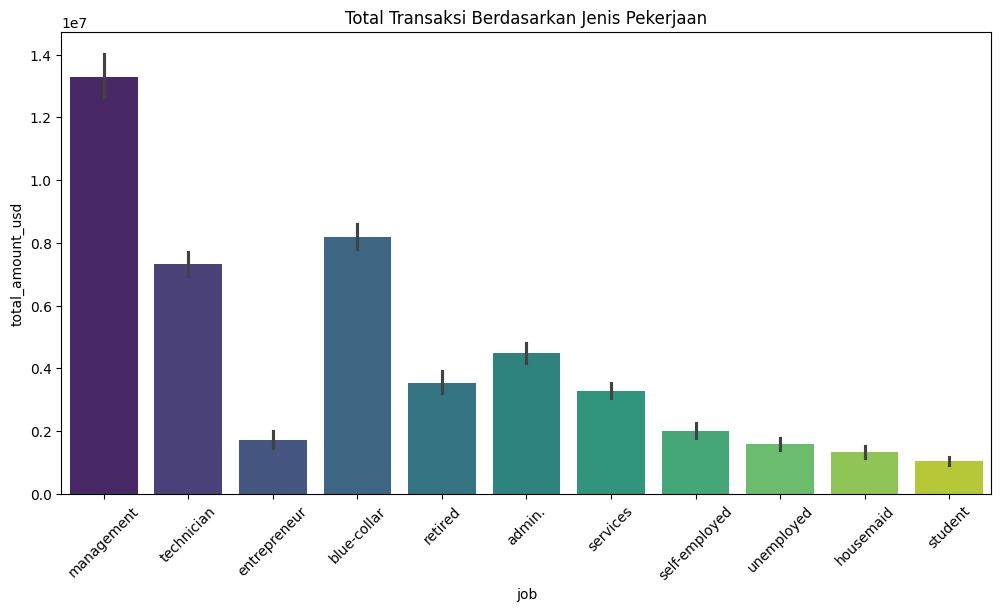

In [ ]:
df = pd.read_pickle('users_data_cleaned.pickle')

plt.figure(figsize=(12,6))
sns.barplot(data=df, x='job', y='total_amount_usd', palette='viridis', estimator=sum)
plt.title('Total Transaksi Berdasarkan Jenis Pekerjaan')
plt.xticks(rotation=45)
plt.show()

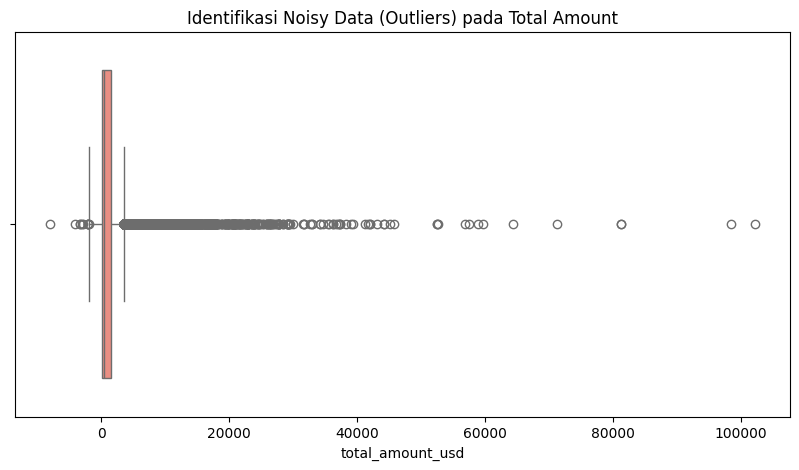

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['total_amount_usd'], color='salmon')
plt.title('Identifikasi Noisy Data (Outliers) pada Total Amount')
plt.show()

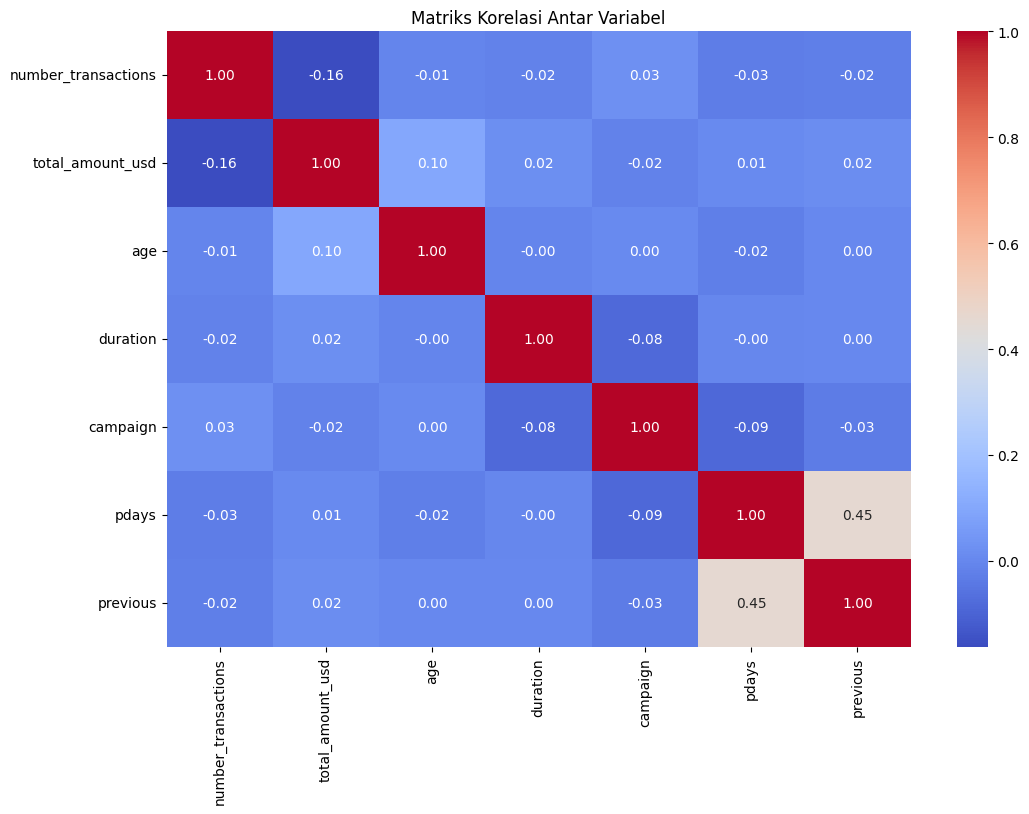

In [ ]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Antar Variabel')
plt.show()